# Similarity Analysis by Job Role & Difficulty
Run the full pipeline (generate LLM answers, compare to ground truth) for every job role,
then report the **max** and **mean** similarity for each difficulty level per job role.

In [12]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Add parent dir so we can import from the Similarity module
sys.path.insert(0, '..')

import similarity_scorer
import answer_generator
from collections import defaultdict

## 1. Load Dataset & Group by Job Role

In [13]:
rows = similarity_scorer.load_ground_truth()
print(f'Total questions loaded: {len(rows)}')

by_role = defaultdict(list)
for r in rows:
    role = r.get('job role', 'Unknown')
    by_role[role].append(r)

print(f'Number of job roles: {len(by_role)}')
for role, role_rows in by_role.items():
    print(f'  {role}: {len(role_rows)} questions')

Total questions loaded: 200
Number of job roles: 16
  Software Engineer: 51 questions
  Database Administrator: 10 questions
  Full-stack Developer: 18 questions
  QA Engineer: 10 questions
  System Architect: 24 questions
  Cybersecurity Engineer: 13 questions
  DevOps Engineer: 21 questions
  Frontend Developer: 17 questions
  Backend Developer: 14 questions
  Machine Learning Engineer: 5 questions
  Distributed Systems Engineer: 5 questions
  Network Engineer: 3 questions
  Systems Programmer: 3 questions
  Database Engineer: 3 questions
  Data Engineer: 2 questions
  AI Engineer: 1 questions


## 2. Run Pipeline — Generate LLM Answers & Compute Similarity

In [14]:
all_results = []

# Map difficulty to experience level
difficulty_to_level = {
    'Easy': 'Junior',
    'Medium': 'Mid',
    'Hard': 'Senior',
}

for role, role_rows in by_role.items():
    print(f'\n--- Processing: {role} ({len(role_rows)} questions) ---')

    # Group questions by difficulty
    by_difficulty = defaultdict(list)
    for r in role_rows:
        by_difficulty[r.get('difficulty', 'Medium')].append(r)

    for difficulty, diff_rows in by_difficulty.items():
        experience_level = difficulty_to_level.get(difficulty, 'Mid')
        questions = [r['question'] for r in diff_rows]

        # Generate LLM answers via Groq with matching experience level
        generated = answer_generator.generate_answers(
            questions=questions,
            job_title=role,
            skills=[],
            experience_level=experience_level,
        )

        # Compute similarity for each question
        for row, gen in zip(diff_rows, generated):
            gen_answer = gen.get('generated_answer', '')
            if not gen_answer.strip():
                continue

            sim = similarity_scorer.compute_similarity(
                generated=gen_answer,
                reference=row['answer'],
            )

            all_results.append({
                'job_role': role,
                'category': row.get('category', ''),
                'difficulty': difficulty,
                'question': row['question'],
                'dataset_answer': row['answer'],
                'generated_answer': gen_answer,
                'similarity': sim,
            })

print(f'\nDone! Processed {len(all_results)} questions total.')



--- Processing: Software Engineer (51 questions) ---

--- Processing: Database Administrator (10 questions) ---

--- Processing: Full-stack Developer (18 questions) ---

--- Processing: QA Engineer (10 questions) ---

--- Processing: System Architect (24 questions) ---

--- Processing: Cybersecurity Engineer (13 questions) ---

--- Processing: DevOps Engineer (21 questions) ---

--- Processing: Frontend Developer (17 questions) ---

--- Processing: Backend Developer (14 questions) ---

--- Processing: Machine Learning Engineer (5 questions) ---

--- Processing: Distributed Systems Engineer (5 questions) ---

--- Processing: Network Engineer (3 questions) ---

--- Processing: Systems Programmer (3 questions) ---

--- Processing: Database Engineer (3 questions) ---

--- Processing: Data Engineer (2 questions) ---

--- Processing: AI Engineer (1 questions) ---

Done! Processed 200 questions total.


## 3. Results DataFrame

In [15]:
results_df = pd.DataFrame(all_results)
print(f'Total results: {len(results_df)}')
results_df.head(10)

Total results: 200


,job_role,category,difficulty,question,dataset_answer,generated_answer,similarity
0,Software Engineer,General Programming,Medium,What is the difference between compilation and...,Compilation translates source code into machin...,Compilation translates the entire source code ...,0.9253
1,Software Engineer,General Programming,Medium,Explain the concept of polymorphism.,Polymorphism allows objects of different class...,Polymorphism lets a single interface represent...,0.8420
2,Software Engineer,General Programming,Medium,"What is an abstract class, and how is it diffe...",An abstract class can't be instantiated and ca...,An abstract class can contain both abstract (u...,0.8830
3,Software Engineer,General Programming,Medium,Describe the principles of Object-Oriented Pro...,"OOP principles include encapsulation, inherita...",OOP is built on four principles: Encapsulation...,0.9184
4,Software Engineer,General Programming,Medium,What is the purpose of a constructor?,A constructor initializes object properties up...,A constructor initializes a newly created obje...,0.8914
5,Software Engineer,General Programming,Medium,Explain the difference between stack and heap ...,Stack memory stores local variables and functi...,"Stack memory stores function call frames, loca...",0.9534
6,Software Engineer,General Programming,Medium,"What is a design pattern, and can you name a few?",Design patterns are solutions to common design...,A design pattern is a reusable solution to a c...,0.8965
7,Software Engineer,General Programming,Medium,"Define the term ""DRY"" in software development.",DRY (Don't Repeat Yourself) advocates for avoi...,DRY stands for “Don’t Repeat Yourself”. It enc...,0.8590
8,Software Engineer,Data Structures,Medium,Describe the difference between a binary searc...,"A binary search tree is hierarchical, maintain...",A binary search tree (BST) stores keys in an o...,0.8953
9,Software Engineer,Data Structures,Medium,What is a linked list and how does it work?,A linked list is a series of nodes each contai...,A linked list is a linear collection of nodes ...,0.9129


## 4. Max Similarity per Difficulty Level for Each Job Role

In [16]:
max_sim = results_df.groupby(['job_role', 'difficulty'])['similarity'].max().unstack(fill_value=0)

for col in ['Easy', 'Medium', 'Hard']:
    if col not in max_sim.columns:
        max_sim[col] = 0.0
max_sim = max_sim[['Easy', 'Medium', 'Hard']]

print('Max Similarity per Difficulty Level for Each Job Role:\n')
max_sim

Max Similarity per Difficulty Level for Each Job Role:



difficulty,Easy,Medium,Hard
job_role,,,
AI Engineer,0.0000,0.0000,0.7377
Backend Developer,0.7099,0.9377,0.8818
Cybersecurity Engineer,0.0000,0.8906,0.8684
Data Engineer,0.0000,0.0000,0.7301
Database Administrator,0.7611,0.9055,0.9026
Database Engineer,0.0000,0.0000,0.7680
DevOps Engineer,0.8165,0.9447,0.9259
Distributed Systems Engineer,0.0000,0.0000,0.9036
Frontend Developer,0.7906,0.9162,0.8934


## 5. Mean Similarity per Difficulty Level for Each Job Role

In [17]:
mean_sim = results_df.groupby(['job_role', 'difficulty'])['similarity'].mean().unstack(fill_value=0)

for col in ['Easy', 'Medium', 'Hard']:
    if col not in mean_sim.columns:
        mean_sim[col] = 0.0
mean_sim = mean_sim[['Easy', 'Medium', 'Hard']].round(4)

print('Mean Similarity per Difficulty Level for Each Job Role:\n')
mean_sim

Mean Similarity per Difficulty Level for Each Job Role:



difficulty,Easy,Medium,Hard
job_role,,,
AI Engineer,0.0000,0.0000,0.7377
Backend Developer,0.7099,0.8465,0.8460
Cybersecurity Engineer,0.0000,0.8362,0.7565
Data Engineer,0.0000,0.0000,0.6824
Database Administrator,0.7611,0.8571,0.8324
Database Engineer,0.0000,0.0000,0.7363
DevOps Engineer,0.8165,0.8681,0.8464
Distributed Systems Engineer,0.0000,0.0000,0.7969
Frontend Developer,0.7906,0.8463,0.8338


In [18]:
# Count and mean similarity per difficulty for each job role
detail = results_df.groupby(['job_role', 'difficulty']).agg(
    count=('similarity', 'count'),
    mean_similarity=('similarity', 'mean'),
).round(4)

# Filter: only keep job roles with at least 5 total results
role_counts = results_df.groupby('job_role')['similarity'].count()
valid_roles = role_counts[role_counts >= 5].index
detail = detail[detail.index.get_level_values('job_role').isin(valid_roles)]

print('Count & Mean Similarity per Difficulty for Each Job Role:\n')
detail


Count & Mean Similarity per Difficulty for Each Job Role:



count  mean_similarity
job_role                     difficulty                        
Backend Developer            Easy            1           0.7099
                             Hard            2           0.8460
                             Medium         11           0.8465
Cybersecurity Engineer       Hard            5           0.7565
                             Medium          8           0.8362
Database Administrator       Easy            1           0.7611
                             Hard            2           0.8324
                             Medium          7           0.8571
DevOps Engineer              Easy            1           0.8165
                             Hard            4           0.8464
                             Medium         16           0.8681
Distributed Systems Engineer Hard            5           0.7969
Frontend Developer           Easy            1           0.7906
                             Hard            4           0.8338
                             Medium         12           0.8463
Full-stack Developer         Hard            5           0.8422
                             Medium         13           0.8493
Machine Learning Engineer    Hard            5           0.6878
QA Engineer                  Easy            1           0.8566
                             Hard            3           0.8649
                             Medium          6           0.8640
Software Engineer            Easy            1           0.8800
                             Hard           19           0.8017
                             Medium         31           0.8826
System Architect             Easy            1           0.8305
                             Hard           16           0.6910
                             Medium          7           0.8871

## 6. Visualization

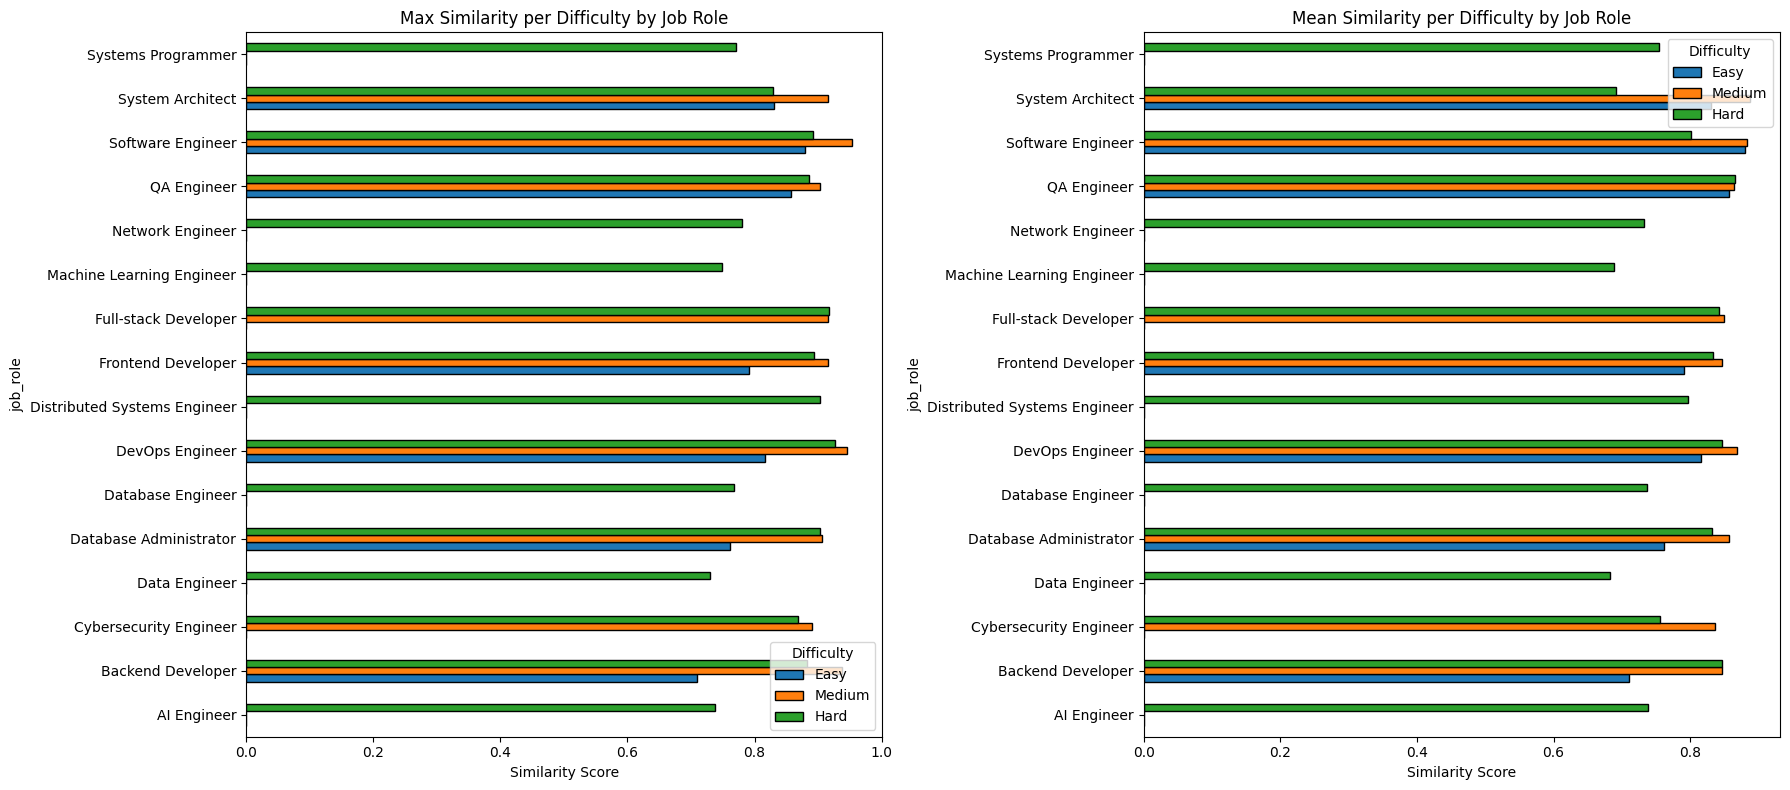

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

max_sim.plot(kind='barh', ax=axes[0], edgecolor='black')
axes[0].set_title('Max Similarity per Difficulty by Job Role')
axes[0].set_xlabel('Similarity Score')
axes[0].legend(title='Difficulty')

mean_sim.plot(kind='barh', ax=axes[1], edgecolor='black')
axes[1].set_title('Mean Similarity per Difficulty by Job Role')
axes[1].set_xlabel('Similarity Score')
axes[1].legend(title='Difficulty')

plt.tight_layout()
plt.show()

## 7. Overall Similarity Summary per Job Role

In [20]:
overall = results_df.groupby('job_role').agg(
    count=('similarity', 'count'),
    mean_similarity=('similarity', 'mean'),
    max_similarity=('similarity', 'max'),
    min_similarity=('similarity', 'min'),
).round(4).sort_values('mean_similarity', ascending=False)

# Filter out job roles with fewer than 5 questions
overall = overall[overall['count'] >= 5]

print('Overall Similarity Summary per Job Role (count >= 5):\n')
overall


Overall Similarity Summary per Job Role (count >= 5):



,count,mean_similarity,max_similarity,min_similarity
job_role,,,,
QA Engineer,10,0.8635,0.9024,0.8245
DevOps Engineer,21,0.8615,0.9447,0.7054
Software Engineer,51,0.8524,0.9534,0.6818
Full-stack Developer,18,0.8473,0.9168,0.7484
Database Administrator,10,0.8426,0.9055,0.7611
Frontend Developer,17,0.8401,0.9162,0.7463
Backend Developer,14,0.8367,0.9377,0.7099
Cybersecurity Engineer,13,0.8056,0.8906,0.6404
Distributed Systems Engineer,5,0.7969,0.9036,0.7157


In [23]:
mean_of_max = overall['mean_similarity'].mean()
print(f'Mean of Similarities across all Job Roles: {mean_of_max:.4f}')

Mean of Similarities across all Job Roles: 0.8171
